# Real data — does the snooping gap appear in the wild?

The SAME gap machine (`pipeline.sweep`) as the synthetic core, fed a different `make_splits` provider. Internal validity (synthetic) is established in `01_core_snooping.ipynb`; here we test **external validity** on real loan data.

## Setup

In [1]:
import sys, os
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "snooping_backend")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
from snooping_backend.pipeline import sweep, synthetic_splits
from snooping_backend.mlp import train, accuracy, sample_config
from snooping_backend.data_loan import load_loan, loan_provider
from snooping_backend.data_finance import load_finance, finance_provider

N_values = [1, 2, 5, 10, 20, 50, 100]
R = 12

## Loan default (UCI) vs the synthetic lab
Does the winner's curse measured exactly on synthetic data also appear on real, messy loan data? Same machine, two providers.

/Users/davi/Desktop/RHUL_Final/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


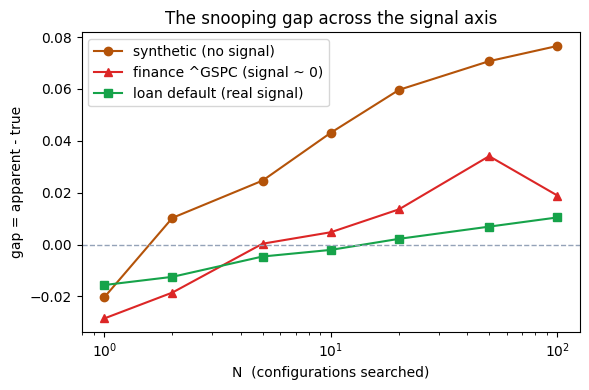

   N    synth     loan   finance
   1    -0.020   -0.016    -0.029
   2    +0.010   -0.012    -0.019
   5    +0.025   -0.005    +0.000
  10    +0.043   -0.002    +0.005
  20    +0.060   +0.002    +0.014
  50    +0.071   +0.007    +0.034
 100    +0.077   +0.010    +0.019


In [2]:
# The SAME machine on three providers across the signal axis:
#   synthetic (no signal) - loan (real signal) - finance (signal ~ 0).
gap_syn = sweep(synthetic_splits(1, 20, 0.0, [1000, 200, 20000]), N_values, np.random.default_rng(0), R=R, epochs=40)

Xl, yl = load_loan()
gap_loan = sweep(loan_provider(Xl, yl, [1500, 200, 8000]), N_values, np.random.default_rng(0), R=R, epochs=60)

Xf, yf, rf = load_finance()
gap_fin = sweep(finance_provider(Xf, yf, [1500, 200, 1000]), N_values, np.random.default_rng(0), R=R, epochs=50)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(N_values, [gap_syn[N]["gap"]  for N in N_values], "o-", color="#b45309", label="synthetic (no signal)")
ax.plot(N_values, [gap_fin[N]["gap"]  for N in N_values], "^-", color="#dc2626", label="finance ^GSPC (signal ~ 0)")
ax.plot(N_values, [gap_loan[N]["gap"] for N in N_values], "s-", color="#16a34a", label="loan default (real signal)")
ax.axhline(0, ls="--", lw=1, color="#94a3b8")
ax.set_xscale("log")
ax.set_xlabel("N  (configurations searched)"); ax.set_ylabel("gap = apparent - true")
ax.set_title("The snooping gap across the signal axis")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(ROOT, "figures", "gap_three_datasets.svg"))
plt.show()

print(f"{'N':>4}    synth     loan   finance")
for N in N_values:
    print(f"{N:>4}    {gap_syn[N]['gap']:+.3f}   {gap_loan[N]['gap']:+.3f}    {gap_fin[N]['gap']:+.3f}")

## Finance ^GSPC — the warning: the searched "edge" is fake
Signal ~ 0, so the gap is almost pure luck (like the no-signal synthetic case). Worse: the
best-on-validation strategy makes no real money out-of-sample - while just holding did.

best-on-validation:  val 0.640  ->  test 0.533   (gap +0.107)  <- apparent edge is luck
cumulative return:   strategy +0.819   vs  buy-and-hold +0.943
simple Sharpe:       strategy +0.064   vs  buy-and-hold +0.070


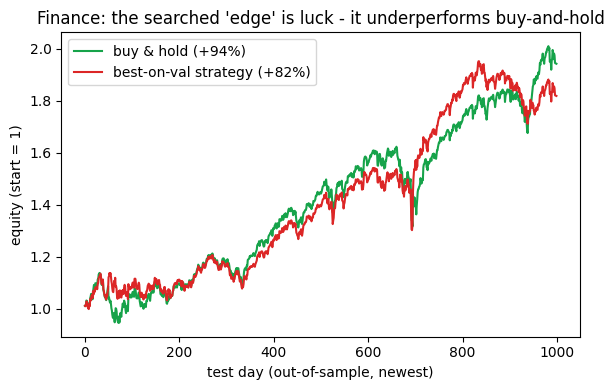

In [3]:
# Deploy the best-on-validation config out-of-sample (walk-forward) and price it.
fin_sizes = [1500, 50, 1000]                       # SMALL val = strong snoop (plan: small val on purpose)
(Xtr, ytr), (Xv, yv), (Xte, yte) = finance_provider(Xf, yf, fin_sizes)(np.random.default_rng(0))
r_test = rf[-fin_sizes[2]:]                        # actual test-period returns (newest, aligned)

rng = np.random.default_rng(7)
best_val, best_model = -1.0, None
for _ in range(50):                                # search 50 configs, keep the best on validation
    c = sample_config(rng)
    m = train(Xtr, ytr, c["width"], c["lr"], epochs=50, seed=int(rng.integers(0, 2**31 - 1)))
    v = accuracy(m, Xv, yv)
    if v > best_val:
        best_val, best_model = v, m

with torch.no_grad():
    pred = best_model(torch.tensor(Xte, dtype=torch.float32)).argmax(1).numpy()
test_acc = float((pred == yte).mean())

position = np.where(pred == 1, 1.0, -1.0)          # long if predicted up, short if down
strat = position * r_test
equity_strat, equity_hold = np.cumprod(1 + strat), np.cumprod(1 + r_test)
sharpe = lambda x: float(x.mean() / x.std())       # simple Sharpe (mean / std)

print(f"best-on-validation:  val {best_val:.3f}  ->  test {test_acc:.3f}   (gap {best_val - test_acc:+.3f})  <- apparent edge is luck")
print(f"cumulative return:   strategy {equity_strat[-1]-1:+.3f}   vs  buy-and-hold {equity_hold[-1]-1:+.3f}")
print(f"simple Sharpe:       strategy {sharpe(strat):+.3f}   vs  buy-and-hold {sharpe(r_test):+.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(equity_hold,  color="#16a34a", label=f"buy & hold ({equity_hold[-1]-1:+.0%})")
ax.plot(equity_strat, color="#dc2626", label=f"best-on-val strategy ({equity_strat[-1]-1:+.0%})")
ax.set_xlabel("test day (out-of-sample, newest)"); ax.set_ylabel("equity (start = 1)")
ax.set_title("Finance: the searched 'edge' is luck - it underperforms buy-and-hold")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(ROOT, "figures", "finance_equity.svg"))
plt.show()